#### 1. Setup

Imports, plot style, and pandas display options.


In [233]:
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates
from scipy import stats

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", 50)

#### 2. Config & Constants

Paths, station list, coordinates, forecast horizons, lookback window.


In [234]:
BASE_DIR = Path("AQI_DATA_024_025")
YEAR_DIRS = ["024", "025"]
STATIONS = ["Bhaktapur", "Khumaltar", "Ratnapark", "Shankhapark"]
PM25_COL = "PM2.5"

COORDS = {
    "Bhaktapur": (27.673762, 85.417528),
    "Khumaltar": (27.645986, 85.323808),
    "Ratnapark": (27.700000, 85.310000),
    "Shankhapark": (27.722654, 85.222836),
}

FORECAST_HORIZONS = [24, 48, 72]
LOOKBACK = 168

OUT_DIR = Path("processed")
OUT_DIR.mkdir(exist_ok=True)

EPA_UNHEALTHY = 55.5


#### 3. Helper Functions

`gap_lengths()` and `iqr_outlier_pct()`, reused across later sections.


In [235]:
def gap_lengths(is_missing):
    """Length of every run of consecutive missing values in a boolean series."""
    grp = (~is_missing).cumsum()
    runs = is_missing.groupby(grp).sum()
    return runs[runs > 0].values

def iqr_outlier_pct(s):
    """% of values in s falling outside the 1.5*IQR fence."""
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    return 100 * ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean()


#### 4. Load Raw Data

Reads each station/year CSV and combines into one raw table.


In [236]:
def load_file(year_dir, station):
    df = pd.read_csv(BASE_DIR / year_dir / f"{station}.csv", na_values=["NA"])
    df["timestamp"] = pd.to_datetime(df["Date"], format="mixed")
    df["station"] = station
    return df[["timestamp", PM25_COL, "station"]]

raw = pd.concat(
    [load_file(year, station) for year in YEAR_DIRS for station in STATIONS],
    ignore_index=True,
)


#### 5. Raw Dataset Overview

Shape, dtypes, and a peek at the raw rows before reindexing.


In [237]:
print("Raw dataset shape:", raw.shape)
print()
print(raw.dtypes)
raw.head()


Raw dataset shape: (68430, 3)

timestamp    datetime64[ns]
PM2.5               float64
station              object
dtype: object


,timestamp,PM2.5,station
0,2024-01-01 00:00:00,NaN,Bhaktapur
1,2024-01-01 01:00:00,NaN,Bhaktapur
2,2024-01-01 02:00:00,NaN,Bhaktapur
3,2024-01-01 03:00:00,NaN,Bhaktapur
4,2024-01-01 04:00:00,NaN,Bhaktapur


#### 6. Date Range Check

Start and end timestamp of the raw data.


In [238]:
print("Start date:", raw["timestamp"].min())
print("End date:", raw["timestamp"].max())

Start date: 2024-01-01 00:00:00
End date: 2025-12-31 23:00:00


#### 7. Timestamp / Duplicate Check

Invalid timestamps and duplicate (station, timestamp) rows.


In [239]:
print("Invalid timestamps:", raw["timestamp"].isna().sum())
print("Duplicate (station, timestamp) records:", raw.duplicated(["station", "timestamp"]).sum())

Invalid timestamps: 0
Duplicate (station, timestamp) records: 0


#### 8. Record Counts

Raw row count per station, before reindexing.


In [240]:
print("Raw record count per station (pre-reindex):")
print(raw.groupby("station").size())
print()
print("Total raw records (pre-reindex):", len(raw))


Raw record count per station (pre-reindex):
station
Bhaktapur      17544
Khumaltar      17544
Ratnapark      16144
Shankhapark    17198
dtype: int64

Total raw records (pre-reindex): 68430


#### 9. Reindex to Hourly Grid

Fills missing hours as NaN rows, merges station coordinates, saves combined CSV.


In [241]:
full_range = pd.date_range(raw["timestamp"].min(), raw["timestamp"].max(), freq="h")

reindexed = []
for station in STATIONS:
    s = raw.loc[raw.station == station].set_index("timestamp")[PM25_COL]
    s = s[~s.index.duplicated()].reindex(full_range)
    reindexed.append(pd.DataFrame({"timestamp": full_range, PM25_COL: s.values, "station": station}))
raw_full_grid = pd.concat(reindexed, ignore_index=True)

coord_df = pd.DataFrame(COORDS, index=["lat", "lon"]).T.reset_index(names="station")

aqi_data = (
    raw_full_grid.merge(coord_df, on="station")
       .sort_values(["station", "timestamp"])
       .reset_index(drop=True)
)

aqi_data.to_csv(OUT_DIR / "raw_hourly_combined.csv", index=False)

print(aqi_data.shape)
aqi_data.head()

(70176, 5)


,timestamp,PM2.5,station,lat,lon
0,2024-01-01 00:00:00,NaN,Bhaktapur,27.673762,85.417528
1,2024-01-01 01:00:00,NaN,Bhaktapur,27.673762,85.417528
2,2024-01-01 02:00:00,NaN,Bhaktapur,27.673762,85.417528
3,2024-01-01 03:00:00,NaN,Bhaktapur,27.673762,85.417528
4,2024-01-01 04:00:00,NaN,Bhaktapur,27.673762,85.417528


#### 10. Before/After Reindex

Compares record counts pre- and post-reindexing.


In [242]:
print("Before reindexing:")
print(f"  Total records: {len(raw)}")
print()
print("After reindexing:")
print(aqi_data.groupby('station').size().rename('records'))
print(f"  Total records: {len(aqi_data)}")


Before reindexing:
  Total records: 68430

After reindexing:
station
Bhaktapur      17544
Khumaltar      17544
Ratnapark      17544
Shankhapark    17544
Name: records, dtype: int64
  Total records: 70176


#### 11. Timeline Range per Station

Min/max timestamp for each station.


In [243]:
aqi_data.groupby("station")["timestamp"].agg(["min", "max"])


,min,max
station,,
Bhaktapur,2024-01-01,2025-12-31 23:00:00
Khumaltar,2024-01-01,2025-12-31 23:00:00
Ratnapark,2024-01-01,2025-12-31 23:00:00
Shankhapark,2024-01-01,2025-12-31 23:00:00


#### 12. Missing Data Summary

Overall missing count and percentage after reindexing.


In [244]:
print(f"Total records: {len(aqi_data)}")
print(f"Total stations: {aqi_data['station'].nunique()}")

missing_count = aqi_data[PM25_COL].isna().sum()
missing_percentage = aqi_data[PM25_COL].isna().mean() * 100

print(f"Total missing values: {missing_count}")
print(f"Overall missing percentage: {missing_percentage:.2f}%")

Total records: 70176
Total stations: 4
Total missing values: 9182
Overall missing percentage: 13.08%


#### 13. Per-Station Missing Summary

Missing % plus gap episode count and longest gap per station.


In [245]:
station_summary = (
    aqi_data.groupby("station")
    .agg(
        Total_Records=(PM25_COL, "size"),
        Missing_Values=(PM25_COL, lambda x: x.isna().sum()),
    )
)

station_summary["Missing_Percentage"] = (
    station_summary["Missing_Values"] / station_summary["Total_Records"] * 100
).round(2)

def gap_episode_stats(s):
    gl = gap_lengths(s.isna())
    return pd.Series({
        "Gap_Episodes": len(gl),
        "Longest_Gap_h": int(gl.max()) if len(gl) else 0,
    })

gap_stats = aqi_data.groupby("station")[PM25_COL].apply(gap_episode_stats).unstack()
station_summary = station_summary.join(gap_stats)

station_summary

,Total_Records,Missing_Values,Missing_Percentage,Gap_Episodes,Longest_Gap_h
station,,,,,
Bhaktapur,17544,3175,18.10,174,836
Khumaltar,17544,507,2.89,45,54
Ratnapark,17544,3533,20.14,48,1488
Shankhapark,17544,1967,11.21,29,1011


#### 14. Data Overview

Shape, column types, memory usage.

In [246]:
aqi_data.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70176 entries, 0 to 70175
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  70176 non-null  datetime64[ns]
 1   PM2.5      60994 non-null  float64       
 2   station    70176 non-null  object        
 3   lat        70176 non-null  float64       
 4   lon        70176 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 6.1 MB


#### 15. Duplicate Check

Confirms no duplicate rows or duplicate (station, timestamp) pairs.

In [247]:
print("duplicate rows:", aqi_data.duplicated().sum())
print("duplicate (station, timestamp):", aqi_data.duplicated(["station", "timestamp"]).sum())

duplicate rows: 0
duplicate (station, timestamp): 0


#### 16. Timestamp Sanity Checks

Dtype, no NaT, no duplicates, sorted per station.

In [248]:
checks = pd.Series({
    "datetime dtype": pd.api.types.is_datetime64_any_dtype(aqi_data["timestamp"]),
    "no NaT": aqi_data["timestamp"].notna().all(),
    "no dup (station, ts)": aqi_data.duplicated(["station", "timestamp"]).sum() == 0,
    "sorted per station": aqi_data.groupby("station")["timestamp"].apply(lambda s: s.is_monotonic_increasing).all(),
})
checks

datetime dtype          True
no NaT                  True
no dup (station, ts)    True
sorted per station      True
dtype: bool

#### 17. Missing Hours per Station

Count of NaN PM2.5 rows per station on the full grid.

In [249]:
full_data = aqi_data.copy()
full_data.groupby("station")[PM25_COL].apply(lambda s: s.isna().sum()).rename("missing_hours")

station
Bhaktapur      3175
Khumaltar       507
Ratnapark      3533
Shankhapark    1967
Name: missing_hours, dtype: int64

#### 18. Hourly Continuity Check

Confirms consecutive rows are exactly 1 hour apart.

In [250]:
gaps = full_data.groupby("station")["timestamp"].diff()
gaps.value_counts().head(5)

timestamp
0 days 01:00:00    70172
Name: count, dtype: int64

#### 19. Descriptive Statistics

Mean, std, quartiles, and skew of PM2.5 per station.

In [251]:
desc = aqi_data.groupby("station")[PM25_COL].describe()
desc["skew"] = aqi_data.groupby("station")[PM25_COL].apply(lambda s: stats.skew(s.dropna()))
desc

,count,mean,std,min,25%,50%,75%,max,skew
station,,,,,,,,,
Bhaktapur,14369.0,44.470916,35.096488,1.926667,16.950000,36.670000,62.471667,314.798332,1.564562
Khumaltar,17037.0,41.166101,31.871480,0.948333,14.210527,34.413560,60.215001,242.033901,1.125511
Ratnapark,14011.0,54.142521,37.729143,2.001667,21.409167,47.668333,79.042500,310.871667,0.930897
Shankhapark,15577.0,42.773666,31.893882,1.696552,17.435000,35.343333,59.545000,235.619999,1.387638


#### 20. Sensor Sanity Checks

Negative values, implausible highs, and stuck-sensor runs.

In [252]:
PHYSICAL_MAX = 1000.0

def longest_run(s):
    s = s.dropna()
    if s.empty:
        return 0
    return s.groupby(s.ne(s.shift()).cumsum()).transform("size").max()

anomalies = aqi_data.groupby("station")[PM25_COL].agg(
    negatives=lambda s: (s < 0).sum(),
    implausible=lambda s: (s > PHYSICAL_MAX).sum(),
    longest_run=longest_run,
)
anomalies

,negatives,implausible,longest_run
station,,,
Bhaktapur,0,0,1
Khumaltar,0,0,1
Ratnapark,0,0,1
Shankhapark,0,0,2


#### 21. Cross-Station Duplicate Values

Checks for identical PM2.5 readings across stations at the same hour.

In [253]:
wide = aqi_data.pivot_table(index="timestamp", columns="station", values=PM25_COL)
same_value_hits = wide.apply(lambda row: row.dropna().duplicated().any(), axis=1).sum()
print("timestamps with 2+ stations matching exactly:", same_value_hits)

timestamps with 2+ stations matching exactly: 0


#### 22. Data Quality Scorecard

Combines all profiling checks into one table per station.

In [254]:
rows = []
for s in STATIONS:
    full = full_data.loc[full_data.station == s, PM25_COL]
    ok = full.dropna()
    gl = gap_lengths(full.isna())
    rows.append({
        "station": s,
        "completeness_%": round(full.notna().mean() * 100, 1),
        "n_gaps": len(gl),
        "max_gap_h": int(gl.max()) if len(gl) else 0,
        "outlier_%": round(iqr_outlier_pct(ok), 2),
        "negatives": int((ok < 0).sum()),
        "implausible": int((ok > PHYSICAL_MAX).sum()),
        "mean_pm25": round(ok.mean(), 1),
        "%_hours_unhealthy": round((ok > EPA_UNHEALTHY).mean() * 100, 1),
    })

scorecard = pd.DataFrame(rows).set_index("station")
scorecard.to_csv(OUT_DIR / "data_quality_scorecard.csv")
scorecard

,completeness_%,n_gaps,max_gap_h,outlier_%,negatives,implausible,mean_pm25,%_hours_unhealthy
station,,,,,,,,
Bhaktapur,81.9,174,836,2.46,0,0,44.5,31.1
Khumaltar,97.1,45,54,1.36,0,0,41.2,28.8
Ratnapark,79.9,48,1488,0.78,0,0,54.1,43.0
Shankhapark,88.8,29,1011,2.34,0,0,42.8,28.3


#### 23. Time Features for EDA

Hour, day-of-week, month, season columns.

In [255]:
full_data["hour"] = full_data.timestamp.dt.hour
full_data["dow"] = full_data.timestamp.dt.dayofweek
full_data["day_name"] = full_data.timestamp.dt.day_name()
full_data["month"] = full_data.timestamp.dt.month
full_data["date"] = full_data.timestamp.dt.date

def season(m):
    return {12: "Winter", 1: "Winter", 2: "Winter",
            3: "Pre-monsoon", 4: "Pre-monsoon", 5: "Pre-monsoon",
            6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon"}.get(m, "Post-monsoon")

full_data["season"] = full_data.month.map(season)
valid = full_data.dropna(subset=[PM25_COL]).copy()

#### 24. Distribution Plot

Raw vs log1p histogram of PM2.5.

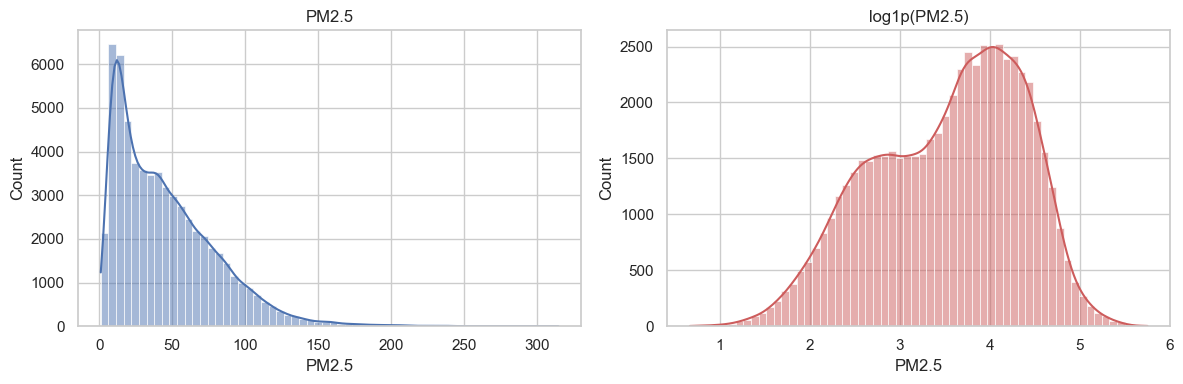

In [256]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(valid[PM25_COL], bins=60, kde=True, ax=ax[0])
sns.histplot(np.log1p(valid[PM25_COL]), bins=60, kde=True, ax=ax[1], color="indianred")
ax[0].set_title("PM2.5"); ax[1].set_title("log1p(PM2.5)")
plt.tight_layout();
plt.show()

#### 25. Boxplot by Station

PM2.5 spread per station plus IQR outlier percentage.

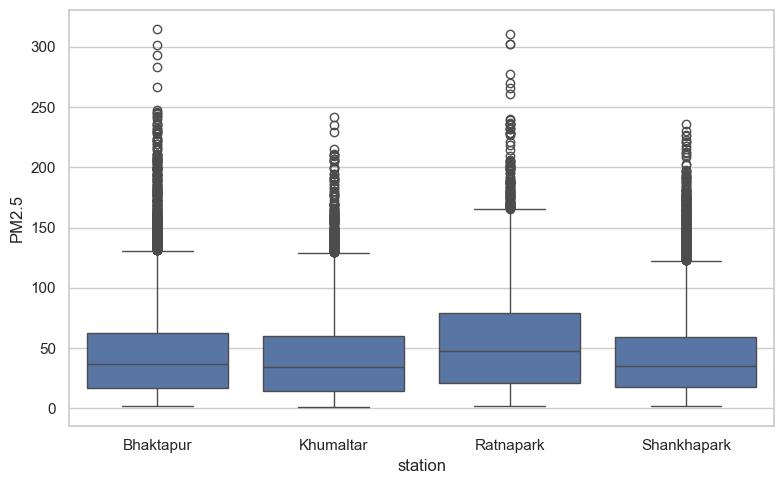

station
Bhaktapur      2.46
Khumaltar      1.36
Ratnapark      0.78
Shankhapark    2.34
Name: outlier_%, dtype: float64

In [257]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=valid, x="station", y=PM25_COL, ax=ax)
plt.tight_layout();
plt.show()

valid.groupby("station")[PM25_COL].apply(iqr_outlier_pct).round(2).rename("outlier_%")

#### 26. Full Time Series

One line plot per station across the whole period.

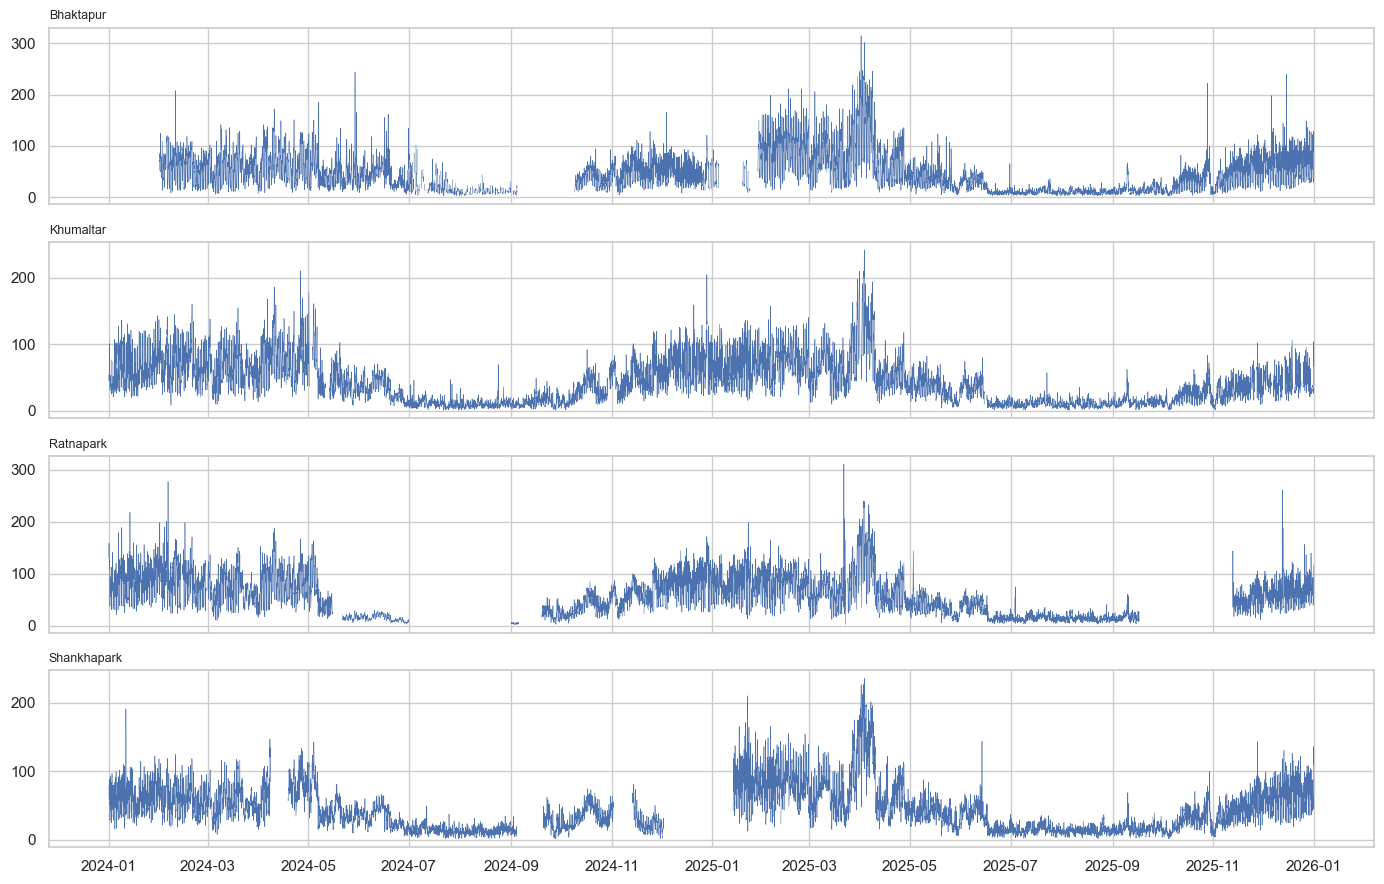

In [258]:
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
for ax, s in zip(axes, STATIONS):
    d = full_data[full_data.station == s]
    ax.plot(d.timestamp, d[PM25_COL], lw=0.4)
    ax.set_title(s, loc="left", fontsize=9)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout();
plt.show()

#### 27. Daily Mean Trend

Daily average PM2.5 per station over time.

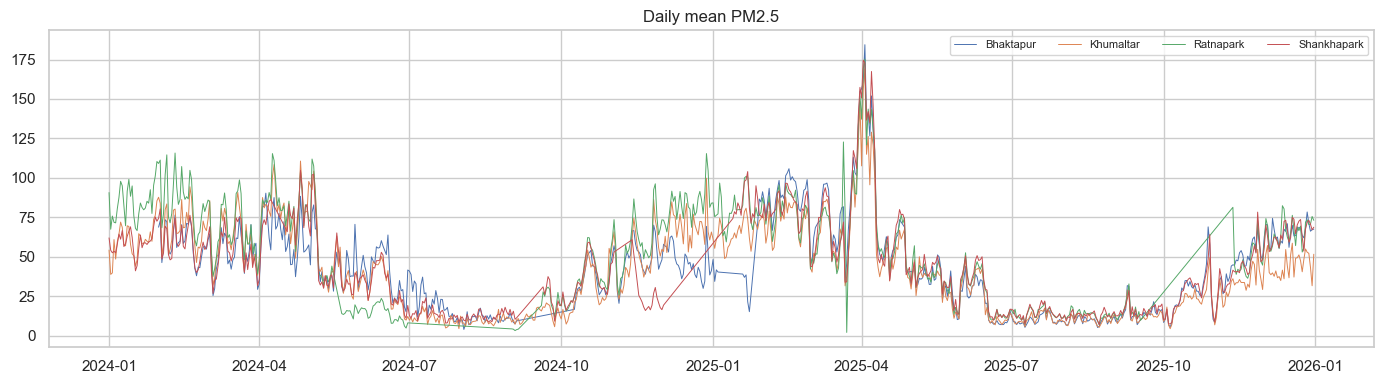

In [259]:
daily = valid.groupby(["station", "date"])[PM25_COL].mean().reset_index()
daily["date"] = pd.to_datetime(daily.date)
fig, ax = plt.subplots(figsize=(14, 4))
for s in STATIONS:
    d = daily[daily.station == s]
    ax.plot(d.date, d[PM25_COL], lw=0.7, label=s)
ax.legend(ncol=4, fontsize=8); ax.set_title("Daily mean PM2.5")
plt.tight_layout(); plt.show()

#### 28. Day-of-Week Pattern

PM2.5 boxplot by weekday.

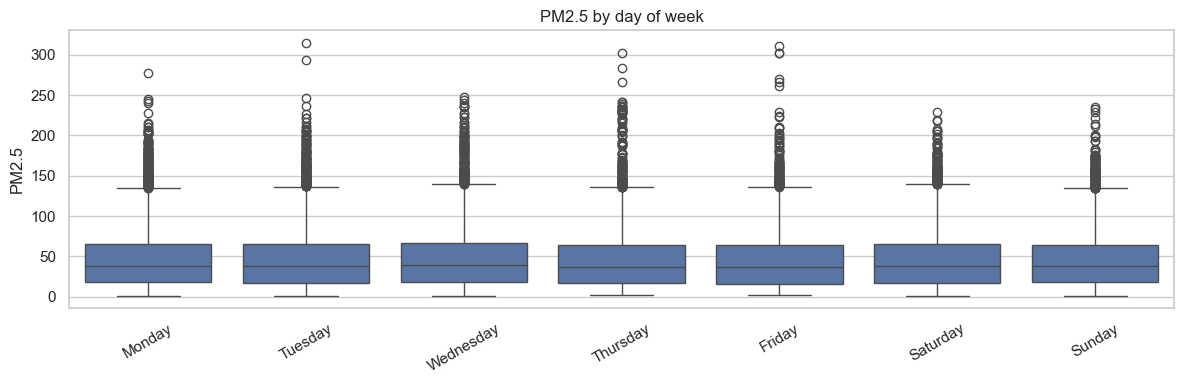

In [260]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(data=valid, x="day_name", y=PM25_COL, order=order)
plt.xticks(rotation=30); plt.title("PM2.5 by day of week"); plt.xlabel("")
plt.tight_layout();
plt.show()

#### 29. Monthly Pattern

Mean PM2.5 by month per station.

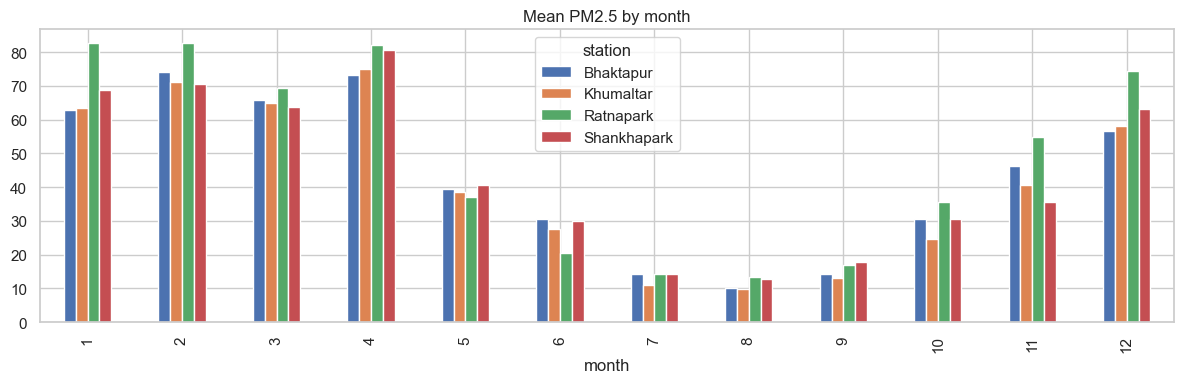

In [261]:
valid.groupby(["station", "month"])[PM25_COL].mean().unstack("station").plot(kind="bar", figsize=(12, 4))
plt.title("Mean PM2.5 by month");
plt.tight_layout();
plt.show()

#### 30. Seasonal Pattern

PM2.5 by season (winter/pre-monsoon/monsoon/post-monsoon) per station.

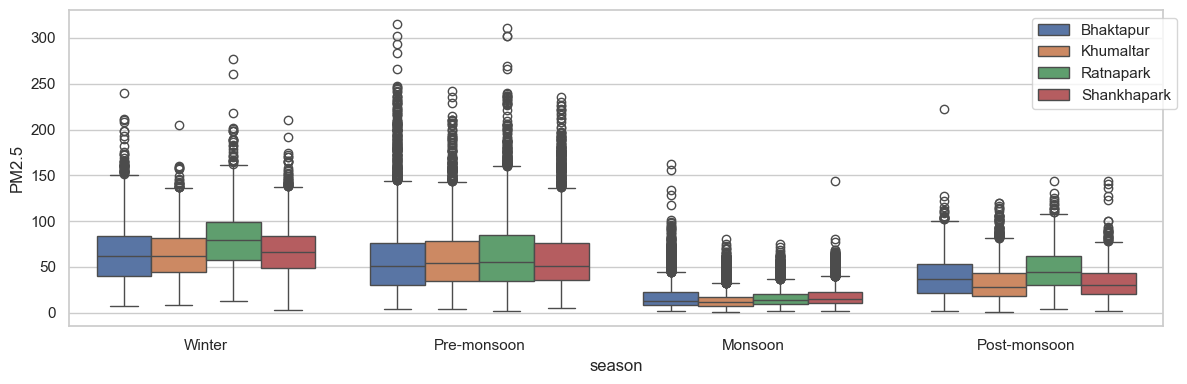

In [262]:
order = ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]
sns.boxplot(data=valid, x="season", y=PM25_COL, hue="station", order=order)
plt.legend(bbox_to_anchor=(1.02, 1));
plt.tight_layout();
plt.show()

#### 31. Diurnal Pattern

Mean PM2.5 by hour of day, with std band.

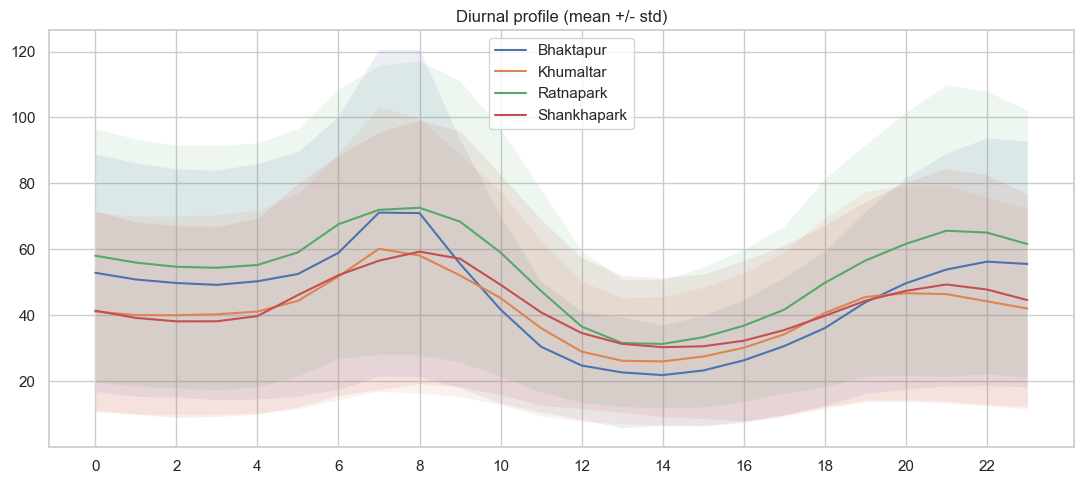

In [263]:
fig, ax = plt.subplots(figsize=(11, 5))
for s in STATIONS:
    g = valid[valid.station == s].groupby("hour")[PM25_COL].agg(["mean", "std"])
    ax.plot(g.index, g["mean"], label=s)
    ax.fill_between(g.index, g["mean"] - g["std"], g["mean"] + g["std"], alpha=0.1)
ax.set_xticks(range(0, 24, 2)); ax.legend(); ax.set_title("Diurnal profile (mean +/- std)")
plt.tight_layout();
plt.show()

#### 32. Month x Hour Heatmap

Mean PM2.5 across month and hour combinations.

In [ ]:
hm = valid.groupby(["month", "hour"])[PM25_COL].mean().unstack("hour")
sns.heatmap(hm, cmap="YlOrRd")
plt.title("Mean PM2.5 by month x hour"); 
plt.tight_layout();
plt.show()

#### 33. Trend/Seasonal/Residual Decomposition

Manual rolling-mean decomposition for Ratnapark, Jan-Feb 2025.

In [ ]:
def decompose(s, period=24):
    s = s.interpolate(limit_direction="both")
    trend = s.rolling(period, center=True, min_periods=period // 2).mean()
    detrended = s - trend
    hour = np.arange(len(s)) % period
    profile = pd.Series(detrended.values, index=hour).groupby(level=0).mean()
    seasonal = pd.Series(hour, index=s.index).map(profile)
    return pd.DataFrame({"observed": s, "trend": trend, "seasonal": seasonal, "residual": detrended - seasonal})

series = full_data[full_data.station == "Ratnapark"].set_index("timestamp")[PM25_COL].loc["2025-01-01":"2025-02-15"]
d = decompose(series)
fig, axes = plt.subplots(4, 1, figsize=(13, 7), sharex=True)
for ax, col in zip(axes, d.columns):
    ax.plot(d.index, d[col], lw=0.8); ax.set_ylabel(col)
axes[0].set_title("Ratnapark, Jan-Feb 2025")
plt.tight_layout(); plt.show()

#### 34. Rolling Averages

24h and 7-day rolling mean over raw PM2.5 (Ratnapark).

In [ ]:
s = full_data[full_data.station == "Ratnapark"].set_index("timestamp")[PM25_COL]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s, lw=0.3, alpha=0.5, label="raw")
ax.plot(s.rolling(24, min_periods=12).mean(), label="24h mean")
ax.plot(s.rolling(168, min_periods=84).mean(), label="7d mean")
ax.legend();
plt.tight_layout();
plt.show()

#### 35. Station Correlation

Pairwise correlation heatmap across all stations.

In [ ]:
wide_full = full_data.pivot_table(index="timestamp", columns="station", values=PM25_COL)
corr = wide_full.corr()
sns.heatmap(corr, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise correlation");
plt.tight_layout(); plt.show()
corr